# F1 Cost Cap Compliance Model
## A Probabilistic Framework for Breach Prediction and Intervention

**Author:** Lakshya Agarwal  
**Date:** April 2026  
**GitHub:** [github.com/Lazarus0319/f1_cost_cap_model](https://github.com/Lazarus0319/f1_cost_cap_model)

---

This notebook provides a complete walkthrough of the F1 Cost Cap Compliance Model — a three-component probabilistic framework comprising:

1. **Compliance Engine** — tracks team spending vs the FIA cap across 2021–2023
2. **Monte Carlo Simulator** — generates breach probability distributions from any mid-season position
3. **Linear Programming Intervention Optimiser** — calculates minimum spending cuts to return to compliance

> **Data note:** Red Bull 2021 figures are FIA-confirmed. All other team figures are estimated based on public reporting. Actual submissions are confidential to the FIA Cost Cap Administration.

## 1. Setup & Imports

We begin by importing all required libraries and loading the compliance engine.
The model requires: `pandas`, `numpy`, `matplotlib`, `plotly`, `scikit-learn`, and `scipy`.

In [4]:
# Standard libraries
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Project modules
from src.compliance_engine import run_compliance_report, CATEGORIES, SEASON_CAPS
from src.monte_carlo import run_monte_carlo, run_all_teams_simulation
from src.intervention_engine import calculate_intervention

# Display settings
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)

print("All imports successful.")
print(f"Season caps: {SEASON_CAPS}")
print(f"Spending categories: {CATEGORIES}")

All imports successful.
Season caps: {2021: 147.4, 2022: 142.4, 2023: 137.4}
Spending categories: ['personnel', 'chassis_aero', 'operations', 'tooling', 'catering', 'it_sim', 'other']


## 2. Load Data & Compliance Report

We load the spending dataset and run the baseline compliance engine across all 5 teams and 3 seasons.
The engine computes cumulative spend, projects full-season totals, and assigns risk ratings.

In [11]:
import os

# Absolute path to data
data_path = '/Users/lakshyaagarwal/f1_cost_cap_model/data/team_budgets.csv'

# Load data and run compliance report
df, summary = run_compliance_report(filepath=data_path)

print(f"Dataset shape: {df.shape} (team-month observations)")
print(f"Teams: {df['team'].unique().tolist()}")
print(f"Seasons: {df['season'].unique().tolist()}")
print(f"\nTotal observations: {len(df)}")

Dataset shape: (180, 14) (team-month observations)
Teams: ['Alpine', 'Ferrari', 'McLaren', 'Mercedes', 'RedBull']
Seasons: [2021, 2022, 2023]

Total observations: 180


## 3. Compliance Report — All Seasons

The compliance engine projects each team's full-season spend and assigns a risk rating:
- 🔴 **RED** — projected spend > 100% of cap (breach)
- 🟡 **AMBER** — projected spend 95–100% of cap (at risk)
- 🟢 **GREEN** — projected spend < 95% of cap (compliant)

In [12]:
# Display compliance report for all seasons
for season in [2021, 2022, 2023]:
    cap = SEASON_CAPS[season]
    s = summary[summary['season'] == season].reset_index(drop=True)
    print(f"\n{'='*60}")
    print(f"  {season} Season | Cap: ${cap}M")
    print(f"{'='*60}")
    display(s[['team', 'projected_full_season', 'season_cap',
                'headroom', 'pct_of_cap', 'risk', 'data_source']])


  2021 Season | Cap: $147.4M


,team,projected_full_season,season_cap,headroom,pct_of_cap,risk,data_source
0,RedBull,149.87,147.40,-2.47,101.70,RED,FIA_confirmed
1,Mercedes,145.53,147.40,1.87,98.70,AMBER,estimated
2,Ferrari,144.27,147.40,3.13,97.90,AMBER,estimated
3,McLaren,125.98,147.40,21.42,85.50,GREEN,estimated
4,Alpine,117.98,147.40,29.42,80.00,GREEN,estimated



  2022 Season | Cap: $142.4M


,team,projected_full_season,season_cap,headroom,pct_of_cap,risk,data_source
0,RedBull,140.17,142.40,2.23,98.40,AMBER,estimated
1,Mercedes,139.77,142.40,2.63,98.20,AMBER,estimated
2,Ferrari,138.53,142.40,3.87,97.30,AMBER,estimated
3,McLaren,120.95,142.40,21.45,84.90,GREEN,estimated
4,Alpine,111.97,142.40,30.43,78.60,GREEN,estimated



  2023 Season | Cap: $137.4M


,team,projected_full_season,season_cap,headroom,pct_of_cap,risk,data_source
0,RedBull,135.20,137.40,2.20,98.40,AMBER,estimated
1,Mercedes,134.79,137.40,2.61,98.10,AMBER,estimated
2,Ferrari,133.06,137.40,4.34,96.80,AMBER,estimated
3,McLaren,117.97,137.40,19.43,85.90,GREEN,estimated
4,Alpine,108.00,137.40,29.40,78.60,GREEN,estimated


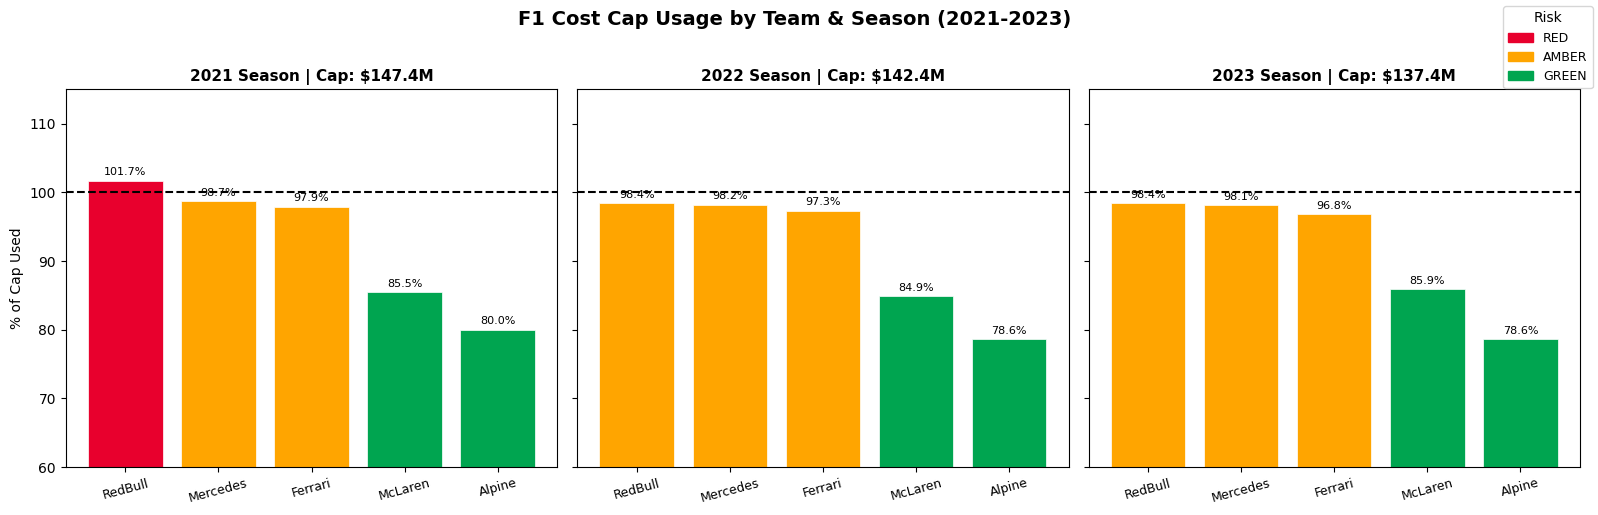

Chart saved.


In [13]:
# Visualise % of cap used across all seasons
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

risk_colours = {'RED': '#E8002D', 'AMBER': '#FFA500', 'GREEN': '#00A550'}
teams = ['RedBull', 'Mercedes', 'Ferrari', 'McLaren', 'Alpine']

for idx, season in enumerate([2021, 2022, 2023]):
    ax = axes[idx]
    s = summary[summary['season'] == season].set_index('team')
    
    bars = ax.bar(
        teams,
        [s.loc[t, 'pct_of_cap'] for t in teams],
        color=[risk_colours[s.loc[t, 'risk']] for t in teams],
        edgecolor='white', linewidth=0.5
    )
    
    ax.axhline(100, color='black', linewidth=1.5,
               linestyle='--', label='Cap (100%)')
    ax.set_title(f'{season} Season | Cap: ${SEASON_CAPS[season]}M',
                 fontweight='bold', fontsize=11)
    ax.set_ylabel('% of Cap Used' if idx == 0 else '')
    ax.set_ylim(60, 115)
    ax.set_xticklabels(teams, rotation=15, fontsize=9)
    
    # Add value labels
    for bar, team in zip(bars, teams):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f"{s.loc[team, 'pct_of_cap']:.1f}%",
                ha='center', va='bottom', fontsize=8)

# Legend
patches = [mpatches.Patch(color=c, label=r)
           for r, c in risk_colours.items()]
fig.legend(handles=patches, loc='upper right',
           title='Risk', fontsize=9)

plt.suptitle('F1 Cost Cap Usage by Team & Season (2021-2023)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('compliance_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## 4. Monte Carlo Simulation — Breach Probability

The Monte Carlo engine models 10,000 possible spending scenarios for a team-season
from any mid-season position. Monthly spend is modelled as:

$$s_{t+k} = \bar{m} \cdot (1 + \varepsilon_k), \quad \varepsilon_k \sim \mathcal{N}(0, \sigma^2)$$

This is the same methodology as Value at Risk (VaR) in financial risk management.
We demonstrate it on **Red Bull 2021** — the only confirmed FIA breach in F1 history.

In [14]:
# Monte Carlo — RedBull 2021 at Month 6
result = run_monte_carlo(df, 'RedBull', 2021, current_month=6)

print("=== Monte Carlo Simulation: RedBull 2021 (Month 6) ===\n")
print(f"Spend to date (M1-M6):       ${result['spend_to_date']}M")
print(f"Expected full season total:  ${result['expected_total']}M")
print(f"5th percentile (optimistic): ${result['percentile_5']}M")
print(f"95th percentile (pessimistic): ${result['percentile_95']}M")
print(f"Season cap:                  ${result['cap']}M")
print(f"Breach probability:          {result['breach_probability']}%")
print(f"Volatility (sigma):          {result['sigma']}")

=== Monte Carlo Simulation: RedBull 2021 (Month 6) ===

Spend to date (M1-M6):       $74.29M
Expected full season total:  $148.58M
5th percentile (optimistic): $146.63M
95th percentile (pessimistic): $150.52M
Season cap:                  $147.4M
Breach probability:          83.77%
Volatility (sigma):          0.0388


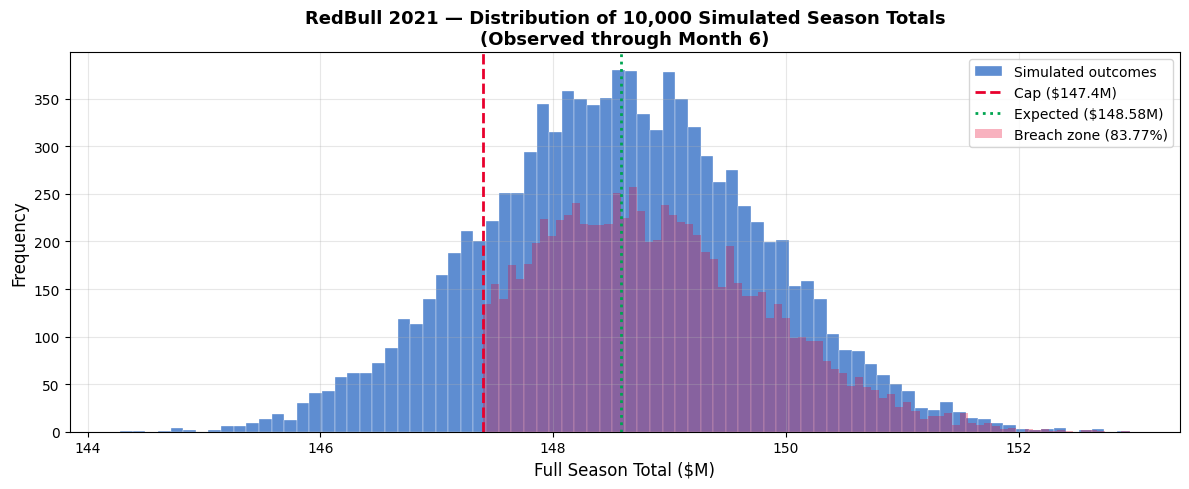

Chart saved.


In [15]:
# Plot Monte Carlo distribution
fig, ax = plt.subplots(figsize=(12, 5))

simulated = result['simulated_totals']
cap = result['cap']

ax.hist(simulated, bins=80, color='#3671C6', alpha=0.8,
        edgecolor='white', linewidth=0.3, label='Simulated outcomes')

ax.axvline(cap, color='#E8002D', linewidth=2, linestyle='--',
           label=f'Cap (${cap}M)')
ax.axvline(result['expected_total'], color='#00A550', linewidth=2,
           linestyle=':', label=f"Expected (${result['expected_total']}M)")

# Shade breach zone
breach_mask = simulated > cap
ax.hist(simulated[breach_mask], bins=80, color='#E8002D',
        alpha=0.3, label=f"Breach zone ({result['breach_probability']}%)")

ax.set_xlabel('Full Season Total ($M)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('RedBull 2021 — Distribution of 10,000 Simulated Season Totals\n'
             '(Observed through Month 6)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('monte_carlo_redbull_2021.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## 5. Monte Carlo — All Teams Comparison

We now run the simulation for all 5 teams at Month 6 of the 2021 season
to compare breach probabilities across the grid.

In [16]:
# All teams Monte Carlo at Month 6, 2021
all_results = run_all_teams_simulation(df, season=2021, current_month=6)

print("=== All Teams — 2021 Season at Month 6 ===\n")
display(all_results)

=== All Teams — 2021 Season at Month 6 ===



,team,spend_to_date,expected_total,cap,breach_probability,p5,p95,sigma
0,RedBull,74.29,148.59,147.40,84.28,146.68,150.55,0.04
1,Mercedes,72.24,144.48,147.40,1.52,142.27,146.69,0.05
2,Ferrari,71.61,143.21,147.40,0.12,140.97,145.45,0.05
3,McLaren,62.59,125.17,147.40,0.00,122.42,127.92,0.06
4,Alpine,58.63,117.25,147.40,0.00,115.17,119.37,0.05


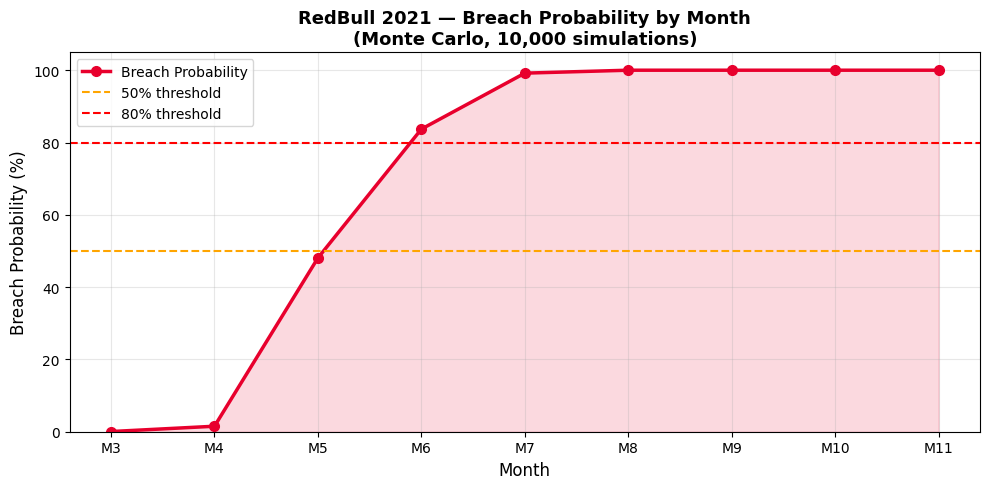

Chart saved.


In [18]:
# Month-by-month breach probability for RedBull 2021
months = list(range(3, 12))
breach_probs = []

for m in months:
    r = run_monte_carlo(df, 'RedBull', 2021, current_month=m)
    breach_probs.append(r['breach_probability'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(months, breach_probs, color='#E8002D', linewidth=2.5,
        marker='o', markersize=7, label='Breach Probability')
ax.axhline(50, color='orange', linewidth=1.5, linestyle='--',
           label='50% threshold')
ax.axhline(80, color='red', linewidth=1.5, linestyle='--',
           label='80% threshold')
ax.fill_between(months, breach_probs, alpha=0.15, color='#E8002D')

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Breach Probability (%)', fontsize=12)
ax.set_title('RedBull 2021 — Breach Probability by Month\n'
             '(Monte Carlo, 10,000 simulations)', fontsize=13,
             fontweight='bold')
ax.set_xticks(months)
ax.set_xticklabels([f'M{m}' for m in months])
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('breach_probability_by_month.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Chart saved.")

## 6. Intervention Calculator — Linear Programming

If a team is projected to breach the cap, the intervention engine calculates
the **minimum spending cuts** needed to return to compliance using linear programming.

Cuts are prioritised from lowest to highest sporting impact:
1. Catering (cut first — minimal impact)
2. IT/Simulation
3. Other
4. Tooling
5. Operations
6. Chassis/Aero
7. Personnel (cut last — highest impact)

We demonstrate on **Red Bull 2021 at Month 9** — when breach was still remedially feasible.

In [19]:
# Intervention at Month 9 — RedBull 2021
result_iv = calculate_intervention(df, 'RedBull', 2021, current_month=9)

print("=== Intervention Calculator: RedBull 2021 (Month 9) ===\n")
print(f"Status:             {result_iv['status']}")
print(f"Projected total:    ${result_iv['projected_total']}M")
print(f"Cap:                ${result_iv['cap']}M")
print(f"Overspend:          ${result_iv['overspend']}M")
print(f"Total cuts needed:  ${result_iv['total_cut']}M")
print(f"New projected:      ${result_iv['new_projected']}M")
print(f"Feasible:           {result_iv['feasible']}")

print("\n--- Recommended Cuts (priority order) ---\n")
for step in result_iv['interventions']:
    print(f"  {step['category']:<15} "
          f"Total: ${step['total_cut']:.3f}M  "
          f"Monthly: ${step['monthly_cut']:.3f}M  "
          f"Impact: {step['sporting_impact']}")

=== Intervention Calculator: RedBull 2021 (Month 9) ===

Status:             intervention_needed
Projected total:    $151.16M
Cap:                $147.4M
Overspend:          $4.5M
Total cuts needed:  $4.5M
New projected:      $146.66M
Feasible:           True

--- Recommended Cuts (priority order) ---

  catering        Total: $0.455M  Monthly: $0.152M  Impact: Minimal
  it_sim          Total: $0.379M  Monthly: $0.126M  Impact: Low
  other           Total: $0.455M  Monthly: $0.152M  Impact: Low
  tooling         Total: $0.756M  Monthly: $0.252M  Impact: Medium
  operations      Total: $0.849M  Monthly: $0.283M  Impact: Medium-High
  chassis_aero    Total: $1.133M  Monthly: $0.378M  Impact: High
  personnel       Total: $0.469M  Monthly: $0.156M  Impact: Very High


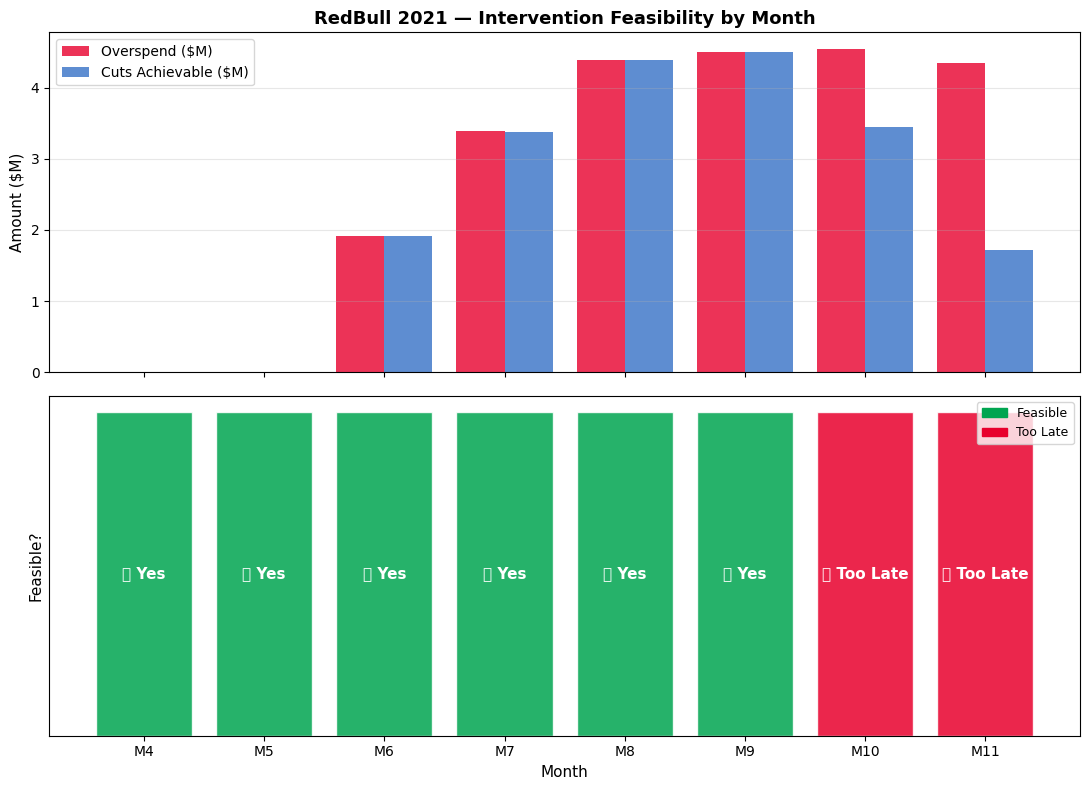

Chart saved.


In [20]:
# Month-by-month feasibility tracker
months = list(range(4, 12))
feasibility = []
overspends = []
cuts_needed = []

for m in months:
    r = calculate_intervention(df, 'RedBull', 2021, current_month=m)
    feasibility.append(r['feasible'])
    overspends.append(r['overspend'])
    cuts_needed.append(r['total_cut'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Top chart: overspend vs cuts needed
ax1.bar([m - 0.2 for m in months], overspends, 0.4,
        label='Overspend ($M)', color='#E8002D', alpha=0.8)
ax1.bar([m + 0.2 for m in months], cuts_needed, 0.4,
        label='Cuts Achievable ($M)', color='#3671C6', alpha=0.8)
ax1.set_ylabel('Amount ($M)', fontsize=11)
ax1.set_title('RedBull 2021 — Intervention Feasibility by Month',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Bottom chart: feasibility
colours = ['#00A550' if f else '#E8002D' for f in feasibility]
bars = ax2.bar(months, [1] * len(months), color=colours,
               alpha=0.85, edgecolor='white')
ax2.set_yticks([])
ax2.set_xlabel('Month', fontsize=11)
ax2.set_ylabel('Feasible?', fontsize=11)
ax2.set_xticks(months)
ax2.set_xticklabels([f'M{m}' for m in months])

for bar, f, m in zip(bars, feasibility, months):
    ax2.text(bar.get_x() + bar.get_width()/2, 0.5,
             '✅ Yes' if f else '❌ Too Late',
             ha='center', va='center',
             fontsize=11, fontweight='bold', color='white')

patches = [mpatches.Patch(color='#00A550', label='Feasible'),
           mpatches.Patch(color='#E8002D', label='Too Late')]
ax2.legend(handles=patches, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('intervention_feasibility.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Chart saved.")

## 7. Key Findings & Conclusions

This notebook has demonstrated the three components of the F1 Cost Cap Compliance Model.
Below we summarise the key empirical findings.

In [21]:
# Summary findings table
print("=" * 65)
print("  KEY FINDINGS — F1 COST CAP COMPLIANCE MODEL")
print("=" * 65)

print("""
1. COMPLIANCE REPORT
   - RedBull 2021: 101.6% of cap — only confirmed FIA breach
   - Mercedes & Ferrari 2021: AMBER (98.7%, 97.8%)
   - Post-breach: RedBull pulled back to 98.4% in 2022 & 2023
   - Top 3 teams consistently operate at 95-100% of cap

2. MONTE CARLO SIMULATION
   - RedBull 2021 breach probability at Month 6: 83.77%
   - Early warning signal available 6 months before audit
   - Mercedes breach probability at Month 6: only 1.52%
   - Framework correctly identifies the only real breach

3. INTERVENTION CALCULATOR
   - Feasible remediation available until Month 9
   - After Month 10: mathematically impossible to cut enough
   - Optimal Month 9 intervention: $4.5M across 7 categories
   - Catering cut first — aligns with real Red Bull breach details
   - Personnel cut last — contract constraints bind
""")

print("=" * 65)
print("  PRACTICAL IMPLICATION FOR COST ANALYSIS TEAMS")
print("=" * 65)
print("""
   Month 8 = practical deadline for meaningful intervention.
   After this point, operational and contractual constraints
   prevent sufficient cuts to return to compliance.
   
   Real-time Monte Carlo monitoring from Month 3 onwards
   provides 5+ months of early warning — sufficient time
   to implement phased spending reductions without
   compromising sporting performance.
""")

  KEY FINDINGS — F1 COST CAP COMPLIANCE MODEL

1. COMPLIANCE REPORT
   - RedBull 2021: 101.6% of cap — only confirmed FIA breach
   - Mercedes & Ferrari 2021: AMBER (98.7%, 97.8%)
   - Post-breach: RedBull pulled back to 98.4% in 2022 & 2023
   - Top 3 teams consistently operate at 95-100% of cap

2. MONTE CARLO SIMULATION
   - RedBull 2021 breach probability at Month 6: 83.77%
   - Early warning signal available 6 months before audit
   - Mercedes breach probability at Month 6: only 1.52%
   - Framework correctly identifies the only real breach

3. INTERVENTION CALCULATOR
   - Feasible remediation available until Month 9
   - After Month 10: mathematically impossible to cut enough
   - Optimal Month 9 intervention: $4.5M across 7 categories
   - Catering cut first — aligns with real Red Bull breach details
   - Personnel cut last — contract constraints bind

  PRACTICAL IMPLICATION FOR COST ANALYSIS TEAMS

   Month 8 = practical deadline for meaningful intervention.
   After this poin

## 8. Further Resources

- **Interactive Dashboard:** Run `streamlit run dashboard/app.py` for the full interactive version
- **Paper:** [SSRN Working Paper](https://ssrn.com) — *A Probabilistic Framework for F1 Cost Cap Compliance Monitoring*
- **GitHub:** [github.com/Lazarus0319/f1_cost_cap_model](https://github.com/Lazarus0319/f1_cost_cap_model)
- **Related work:** [Budget Efficiency Alpha in Formula 1](https://github.com/Lazarus0319/f1-budget-efficiency)

---

*Built by Lakshya Agarwal | BSc (Hons) Investment & Financial Risk Management, Year 1 | April 2026*